In [18]:
import os
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import Normalizer 
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, ImageDataGenerator
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# 1. Cấu hình & Load Dữ liệu
Dùng MobileNetV2 để chuyển ảnh thành Vector (Feature Extraction).
Áp dụng chuẩn hóa (L2 Normalization) 

In [19]:
# Khai báo thư mục chứa dữ liệu ảnh khuôn mặt
DATASET_DIR = 'dataset' 

# Hàm trích xuất ID từ tên file ảnh, ví dụ: 'User.1.1.jpg' -> ID = 1
# Nếu tên file không đúng định dạng sẽ trả về None

def get_id_from_filename(filename):
    """
    Hàm trích xuất ID từ tên file ảnh.
    """
    try:
        parts = filename.split('.')
        if len(parts) >= 3 and parts[0] == "User":
            return int(parts[1]) 
    except:
        pass
    return None

# Hàm load dữ liệu ảnh, trích xuất đặc trưng bằng MobileNetV2 và gán nhãn
# Trả về: X (vector đặc trưng), y (ID), label_map (ánh xạ ID với tên thư mục), feature_extractor, sample_img_path

def load_and_extract_features():
    print(" Đang khởi tạo MobileNetV2...")
    # Khởi tạo model MobileNetV2 đã huấn luyện sẵn trên ImageNet, bỏ lớp phân loại cuối
    feature_extractor = MobileNetV2(weights="imagenet", include_top=False, 
                                    input_shape=(224, 224, 3), pooling='avg')
    
    X = []  # Danh sách vector đặc trưng của từng ảnh
    y = []  # Danh sách ID tương ứng với từng vector
    label_map = {}  # Bảng ánh xạ ID -> tên thư mục (tức là tên người)
    sample_img_path = None # Lưu lại 1 ảnh mẫu để minh họa vector

    # Kiểm tra thư mục dữ liệu có tồn tại không
    if not os.path.exists(DATASET_DIR):
        print("[LỖI] Không tìm thấy dataset!")
        return None, None, None, None, None

    print(" Đang quét và xử lý ảnh...")
    
    # Quét tất cả các thư mục con trong dataset (mỗi thư mục là 1 người)
    dirs = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]
    
    for folder_name in dirs:
        folder_path = os.path.join(DATASET_DIR, folder_name)
        print(f" -> Đang xử lý thư mục: {folder_name}")
        
        # Lấy danh sách file ảnh trong thư mục (chỉ lấy file jpg, png, jpeg)
        image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        
        for filename in image_files:
            img_path = os.path.join(folder_path, filename)
            if sample_img_path is None: sample_img_path = img_path # Lưu lại ảnh đầu tiên làm mẫu

            # ---  LẤY ID TỪ TÊN FILE ---
            person_id = get_id_from_filename(filename)
            
            # Nếu tên file không đúng chuẩn User.ID... thì BỎ QUA
            if person_id is None:
                continue
            
            # Cập nhật map để hiển thị (ID -> Tên Folder)
            if person_id not in label_map:
                label_map[person_id] = folder_name

            # Đọc ảnh từ file
            image = cv2.imread(img_path)
            if image is None: continue

            try:
                # Resize ảnh về 224x224, chuyển thành mảng số, chuẩn hóa đầu vào cho MobileNetV2
                image = cv2.resize(image, (224, 224))
                image = img_to_array(image)
                image = np.expand_dims(image, axis=0)
                image = preprocess_input(image)

                # Trích xuất vector đặc trưng bằng MobileNetV2
                vec = feature_extractor.predict(image, verbose=0)
                X.append(vec[0])
                y.append(person_id)
            except: pass
            
    return np.array(X), np.array(y), label_map, feature_extractor, sample_img_path

# Chạy hàm load dữ liệu, kết quả trả về gồm: 
# X_features: mảng vector đặc trưng, y_labels: mảng ID, label_map: ánh xạ ID-tên, model_mobilenet: model, sample_path: ảnh mẫu
X_features, y_labels, label_map, model_mobilenet, sample_path = load_and_extract_features()

if X_features is not None:
    print(f"\n[KẾT QUẢ] Tổng số mẫu dữ liệu: {len(X_features)}")
    
    # ---  CHUẨN HÓA DỮ LIỆU (LÀM SẠCH VECTOR) ---
    print(" Đang chuẩn hóa vector (L2 Normalization)...")
    scaler = Normalizer(norm='l2')  # Khởi tạo bộ chuẩn hóa L2
    X_features = scaler.transform(X_features)  # Mọi vector đều có độ dài bằng 1
    print(" -> Đã chuẩn hóa xong. Các vector giờ có độ dài bằng 1.")
    # -----------------------------------------------------

    print(f"[KẾT QUẢ] Số lượng lớp (Người): {len(np.unique(y_labels))}")
else:
    print("[LỖI] Không tải được dữ liệu.")


 Đang khởi tạo MobileNetV2...
 Đang quét và xử lý ảnh...
 -> Đang xử lý thư mục: nhanvien_1
 -> Đang xử lý thư mục: nhanvien_2
 -> Đang xử lý thư mục: nhanvien_3
 -> Đang xử lý thư mục: nhanvien_4
 -> Đang xử lý thư mục: nhanvien_5
 -> Đang xử lý thư mục: nhanvien_6
 -> Đang xử lý thư mục: nhanvien_7

[KẾT QUẢ] Tổng số mẫu dữ liệu: 350
 Đang chuẩn hóa vector (L2 Normalization)...
 -> Đã chuẩn hóa xong. Các vector giờ có độ dài bằng 1.
[KẾT QUẢ] Số lượng lớp (Người): 7


# 2.Minh họa Vectto 


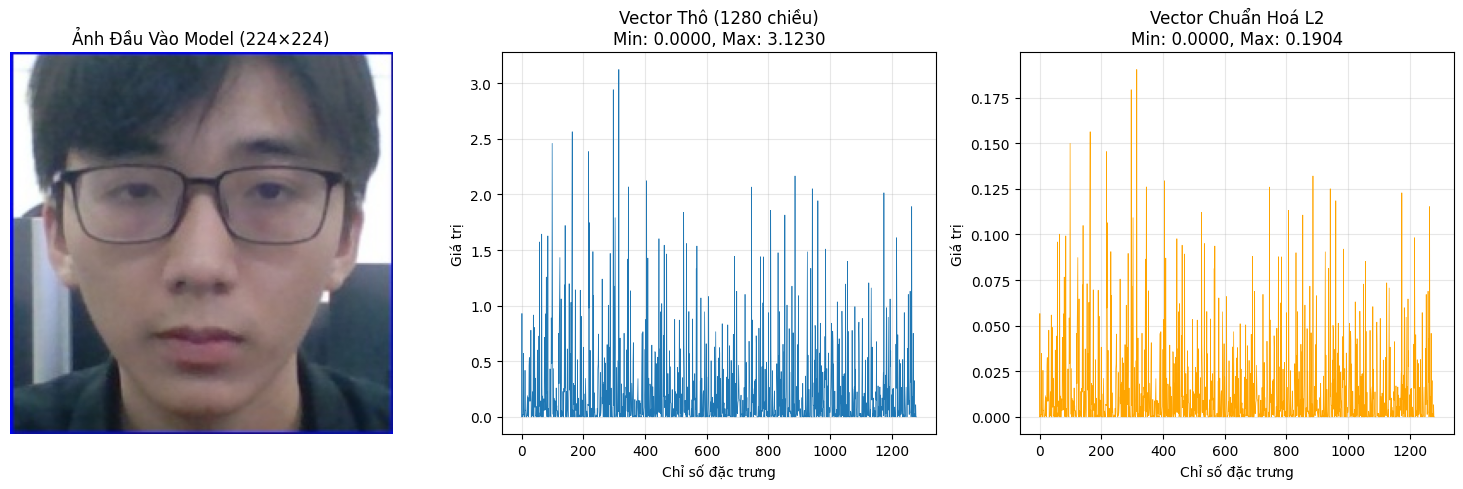


=== 10 GIÁ TRỊ ĐẦU CỦA VECTOR THÔ ===
[0.         0.929446   0.         0.01458447 0.02181202 0.01487221
 0.570369   0.08476446 0.         0.00821165]

=== 10 GIÁ TRỊ ĐẦU CỦA VECTOR CHUẨN HOÁ L2 ===
[0.         0.05667486 0.         0.00088932 0.00133003 0.00090686
 0.03477941 0.00516868 0.         0.00050072]


In [20]:
if sample_path:

    # Đọc ảnh gốc
    img_org = cv2.imread(sample_path)
    if img_org is not None:
        img_rgb = cv2.cvtColor(img_org, cv2.COLOR_BGR2RGB)

        # === Chuẩn bị ảnh input (224×224) ===
        img_resized = cv2.resize(img_org, (224, 224))
        img_input = img_to_array(img_resized)
        img_input = np.expand_dims(img_input, axis=0)
        img_input = preprocess_input(img_input)

        # === Vector thô ===
        vector_raw = model_mobilenet.predict(img_input, verbose=0)[0]

        # === Vector sau chuẩn hóa L2 ===
        vector_norm = vector_raw / np.linalg.norm(vector_raw)

        # === VẼ 1 ẢNH + 2 VECTOR SO SÁNH ===
        plt.figure(figsize=(15, 5))

        # Ảnh 224×224 đưa vào MobileNet (chỉ cần 1 ảnh)
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
        plt.title("Ảnh Đầu Vào Model (224×224)")
        plt.axis('off')

        # Vector thô
        plt.subplot(1, 3, 2)
        plt.plot(vector_raw, linewidth=0.5)
        plt.title(f"Vector Thô (1280 chiều)\nMin: {vector_raw.min():.4f}, Max: {vector_raw.max():.4f}")
        plt.xlabel("Chỉ số đặc trưng")
        plt.ylabel("Giá trị")
        plt.grid(True, alpha=0.3)

        # Vector chuẩn hóa L2
        plt.subplot(1, 3, 3)
        plt.plot(vector_norm, linewidth=0.5, color='orange')
        plt.title(f"Vector Chuẩn Hoá L2\nMin: {vector_norm.min():.4f}, Max: {vector_norm.max():.4f}")
        plt.xlabel("Chỉ số đặc trưng")
        plt.ylabel("Giá trị")
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # In vector
        print("\n=== 10 GIÁ TRỊ ĐẦU CỦA VECTOR THÔ ===")
        print(vector_raw[:10])

        print("\n=== 10 GIÁ TRỊ ĐẦU CỦA VECTOR CHUẨN HOÁ L2 ===")
        print(vector_norm[:10])

    else:
        print("[LỖI] Không thể đọc ảnh mẫu.")


In [21]:
if X_features is not None and len(X_features) > 0:
    # Chia dữ liệu: 80% Train, 20% Test
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y_labels, 
        test_size=0.2, 
        random_state=42,
        stratify=y_labels  # Đảm bảo tỷ lệ mỗi lớp giống nhau ở train/test
    )

    print(f"Số lượng tập Train: {len(X_train)}")
    print(f"Số lượng tập Test: {len(X_test)}")
    
else:
    print("[LỖI] Không có dữ liệu để chia tập.")

Số lượng tập Train: 280
Số lượng tập Test: 70


# 3. Cross-Validation (Đánh giá độ tin cậy)
Kiểm tra tính ổn định của mô hình bằng K-Fold Cross-Validation

In [22]:
from sklearn.model_selection import cross_val_score

if X_features is not None and len(X_features) > 0:
    print("=== CROSS-VALIDATION (5-FOLD) ===\n")
    print(f"{'MÔ HÌNH':<25} | {'MEAN ACCURACY':<15} | {'STD DEV':<10}")
    print("-" * 65)
    
    models_cv = {
        "SVM (RBF Kernel)": SVC(kernel='rbf', C=1.5, gamma='scale', probability=True),
        "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }
    
    cv_results = {}
    for name, model in models_cv.items():
        cv_scores = cross_val_score(model, X_features, y_labels, cv=5, scoring='accuracy', n_jobs=-1)
        cv_results[name] = {'mean': cv_scores.mean(), 'std': cv_scores.std(), 'scores': cv_scores}
        print(f"{name:<25} | {cv_scores.mean()*100:>13.2f}%  | ±{cv_scores.std()*100:>7.2f}%")
    
    print("\n Cross-validation giúp đánh giá độ ổn định của mô hình trên nhiều phân chia dữ liệu khác nhau.")
else:
    print("[LỖI] Không có dữ liệu để thực hiện cross-validation.")

=== CROSS-VALIDATION (5-FOLD) ===

MÔ HÌNH                   | MEAN ACCURACY   | STD DEV   
-----------------------------------------------------------------
SVM (RBF Kernel)          |         96.86%  | ±   5.60%
KNN (k=5)                 |         91.71%  | ±   6.02%
Random Forest             |         88.86%  | ±   6.96%

 Cross-validation giúp đánh giá độ ổn định của mô hình trên nhiều phân chia dữ liệu khác nhau.


# 4. Huấn luyện & So sánh 3 Thuật toán

In [23]:
from sklearn.metrics import precision_recall_fscore_support

if X_features is not None and len(X_features) > 0:
    # Danh sách các mô hình cần so sánh
    models = {
        "SVM (RBF Kernel)": SVC(kernel='rbf', C=1.5, gamma='scale', probability=True),
        "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

    results = {}

    print(f"{'MÔ HÌNH':<20} | {'CV ACCURACY':<13} | {'TEST ACC':<10} | {'PRECISION':<11} | {'RECALL':<11} | {'F1-SCORE':<11} | {'THỜI GIAN':<12}")
    print("-" * 120)

    for name, model in models.items():
        # Đo thời gian train
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Đo độ chính xác trên tập Test
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        
        # Tính Precision, Recall, F1-Score
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
        
        # Lấy CV accuracy từ cross-validation trước đó (nếu có)
        cv_acc = cv_results.get(name, {}).get('mean', 0) if 'cv_results' in globals() else 0
        
        # Lưu kết quả
        results[name] = {
            'cv_accuracy': cv_acc,
            'test_accuracy': acc, 
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'time': train_time, 
            'y_pred': y_pred, 
            'model': model
        }
        
        # Highlight model có CV tốt nhất bằng 
        marker = " " if cv_acc > 0 and cv_acc == max([cv_results.get(n, {}).get('mean', 0) for n in models.keys()]) else ""
        
        print(f"{name:<20} | {cv_acc*100:>11.2f}%  | {acc*100:>8.2f}%  | {precision*100:>9.2f}%  | {recall*100:>9.2f}%  | {f1*100:>9.2f}%  | {train_time:>10.4f}s{marker}")
    
    # Phân tích chi tiết
    print("\n" + "="*120)
    print(" PHÂN TÍCH KẾT QUẢ:")
    print("="*120)
    
    # Tìm model tốt nhất dựa trên CV
    if 'cv_results' in globals():
        best_cv_name = max(results.items(), key=lambda x: x[1]['cv_accuracy'])[0]
        best_test_name = max(results.items(), key=lambda x: x[1]['test_accuracy'])[0]
        
        print(f"\n MÔ HÌNH TỐT NHẤT (theo Cross-Validation): {best_cv_name}")
        print(f"   • CV Accuracy:   {results[best_cv_name]['cv_accuracy']*100:.2f}% (ổn định trên nhiều lần chia dữ liệu)")
        print(f"   • Test Accuracy: {results[best_cv_name]['test_accuracy']*100:.2f}%")
        print(f"   • Độ chênh CV-Test: {abs(results[best_cv_name]['cv_accuracy']*100 - results[best_cv_name]['test_accuracy']*100):.2f}% (càng nhỏ càng tốt)")
        
        if best_cv_name != best_test_name:
            print(f"\n  {best_test_name} có Test Accuracy cao hơn ({results[best_test_name]['test_accuracy']*100:.2f}%), NHƯNG:")
            print(f"   • CV Accuracy chỉ {results[best_test_name]['cv_accuracy']*100:.2f}% (thấp hơn {best_cv_name})")
            print(f"   • Chênh lệch CV-Test: {abs(results[best_test_name]['cv_accuracy']*100 - results[best_test_name]['test_accuracy']*100):.2f}% → Không ổn định!")
            print(f"   → Kết luận: {best_test_name} có thể 'may mắn' trên test set này, {best_cv_name} đáng tin cậy hơn trong thực tế.")
else:
    print("[LỖI] Không có dữ liệu để huấn luyện.")

MÔ HÌNH              | CV ACCURACY   | TEST ACC   | PRECISION   | RECALL      | F1-SCORE    | THỜI GIAN   
------------------------------------------------------------------------------------------------------------------------
SVM (RBF Kernel)     |       96.86%  |   100.00%  |    100.00%  |    100.00%  |    100.00%  |     0.1730s 
KNN (k=5)            |       91.71%  |   100.00%  |    100.00%  |    100.00%  |    100.00%  |     0.0010s
Random Forest        |       88.86%  |    95.71%  |     95.97%  |     95.71%  |     95.71%  |     0.5576s

 PHÂN TÍCH KẾT QUẢ:

 MÔ HÌNH TỐT NHẤT (theo Cross-Validation): SVM (RBF Kernel)
   • CV Accuracy:   96.86% (ổn định trên nhiều lần chia dữ liệu)
   • Test Accuracy: 100.00%
   • Độ chênh CV-Test: 3.14% (càng nhỏ càng tốt)


# 5. So sánh thêm các phương pháp học không giám sát

In [24]:
# --- HỌC KHÔNG GIÁM SÁT: COSINE & L2 ---
def unsupervised_template_matching(X_train, y_train, X_test, y_test, metric='cosine'):
    # Tính template (mean vector) cho mỗi lớp
    unique_labels = np.unique(y_train)
    templates = []
    for label in unique_labels:
        templates.append(X_train[y_train == label].mean(axis=0))
    templates = np.stack(templates)
    # Đánh giá
    t0 = time.time()
    if metric == 'cosine':
        sims = cosine_similarity(X_test, templates)  # shape: (n_test, n_classes)
        y_pred = unique_labels[np.argmax(sims, axis=1)]
    elif metric == 'l2':
        dists = euclidean_distances(X_test, templates)
        y_pred = unique_labels[np.argmin(dists, axis=1)]
    else:
        raise ValueError('metric must be "cosine" or "l2"')
    acc = accuracy_score(y_test, y_pred)
    t1 = time.time() - t0
    return acc, t1, y_pred

# Chạy so sánh các phương pháp
results_unsup = {}
acc_cosine, t_cosine, y_pred_cosine = unsupervised_template_matching(X_train, y_train, X_test, y_test, metric='cosine')
results_unsup['Cosine Similarity'] = {'accuracy': acc_cosine, 'time': t_cosine, 'y_pred': y_pred_cosine}

acc_l2, t_l2, y_pred_l2 = unsupervised_template_matching(X_train, y_train, X_test, y_test, metric='l2')
results_unsup['L2 Distance'] = {'accuracy': acc_l2, 'time': t_l2, 'y_pred': y_pred_l2}

print(f"{'MÔ HÌNH':<20} | {'ĐỘ CHÍNH XÁC':<15} | {'THỜI GIAN (s)':<15}")
print("-" * 60)
for name, res in results_unsup.items():
    print(f"{name:<20} | {res['accuracy']*100:.2f}%          | {res['time']:.4f}s")

MÔ HÌNH              | ĐỘ CHÍNH XÁC    | THỜI GIAN (s)  
------------------------------------------------------------
Cosine Similarity    | 95.71%          | 0.0020s
L2 Distance          | 95.71%          | 0.0013s


# 6. Bảng so sánh kết quả

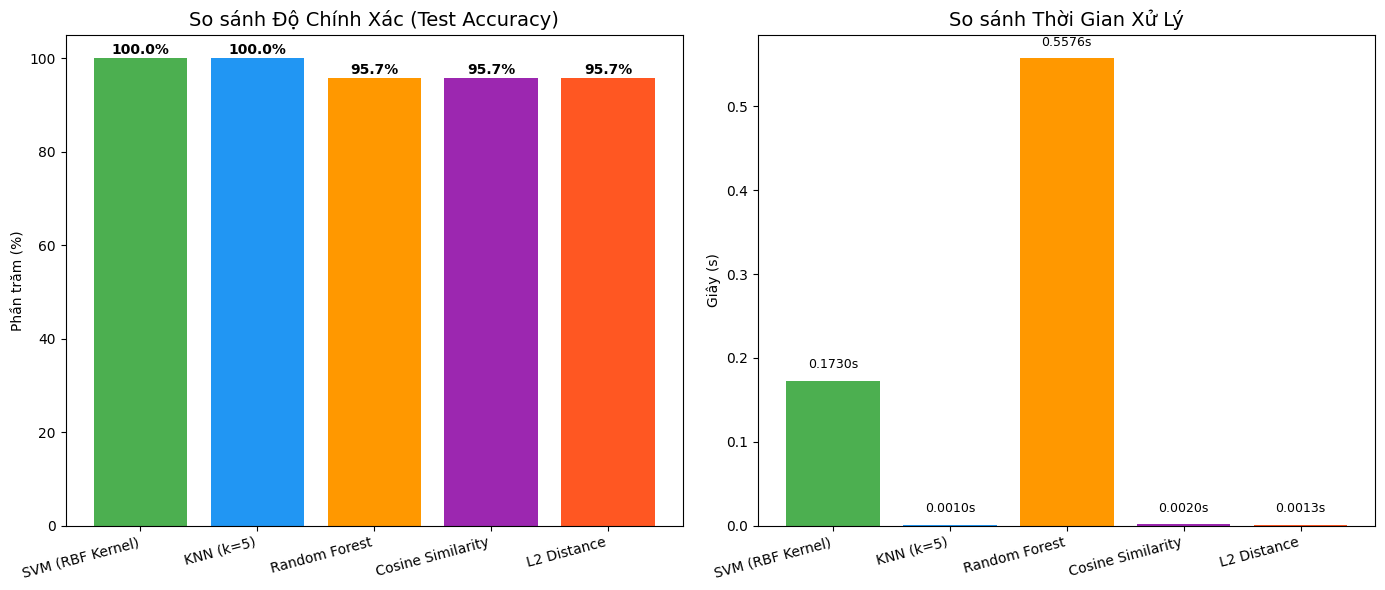

In [25]:
# --- GỘP KẾT QUẢ ĐỂ SO SÁNH ---
all_results = {}

# Chuẩn hóa format dữ liệu từ results (có test_accuracy)
if 'results' in locals():
    for name, data in results.items():
        all_results[name] = {
            'accuracy': data.get('test_accuracy', data.get('accuracy', 0)),  # Tương thích cả 2 format
            'time': data.get('time', 0)
        }

# Thêm kết quả học không giám sát (có accuracy)
if 'results_unsup' in locals():
    all_results.update(results_unsup)

# Vẽ bảng so sánh tổng hợp
names = list(all_results.keys())
accuracies = [all_results[n]['accuracy'] * 100 for n in names]
times = [all_results[n]['time'] for n in names]

plt.figure(figsize=(14, 6))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
bars = plt.bar(names, accuracies, color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#FF5722'])
plt.ylim(0, 105)
plt.title("So sánh Độ Chính Xác (Test Accuracy)", fontsize=14)
plt.ylabel("Phần trăm (%)")
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

# Biểu đồ Training Time
plt.subplot(1, 2, 2)
plt.bar(names, times, color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#FF5722'])
plt.title("So sánh Thời Gian Xử Lý", fontsize=14)
plt.ylabel("Giây (s)")
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(times):
    plt.text(i, v + max(times)*0.02, f"{v:.4f}s", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 7. Liệt kê độ chính xác chi tiết từ thuật toán tốt nhất SVM

--- BÁO CÁO CHI TIẾT CHO SVM (RBF Kernel) ---
              precision    recall  f1-score   support

  nhanvien_1       1.00      1.00      1.00        10
  nhanvien_2       1.00      1.00      1.00        10
  nhanvien_3       1.00      1.00      1.00        10
  nhanvien_4       1.00      1.00      1.00        10
  nhanvien_5       1.00      1.00      1.00        10
  nhanvien_6       1.00      1.00      1.00        10
  nhanvien_7       1.00      1.00      1.00        10

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



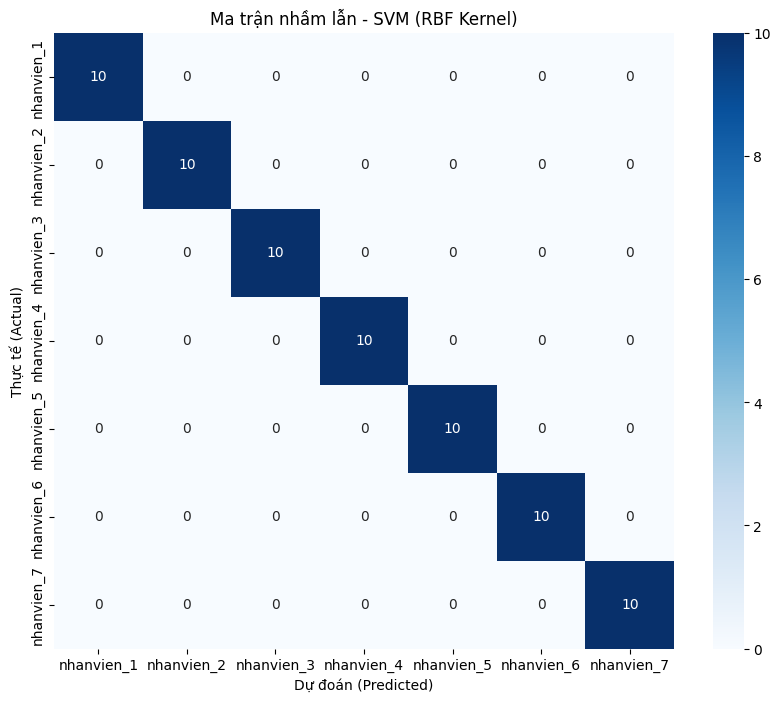

In [26]:
if X_features is not None and len(X_features) > 0:
    # Chọn mô hình tốt nhất (SVM) để vẽ chi tiết
    best_model_name = "SVM (RBF Kernel)"
    
    if best_model_name in results:
        y_pred_svm = results[best_model_name]['y_pred']

        # Lấy danh sách tên người theo thứ tự ID có trong y_test
        # Lưu ý: y_test có thể không chứa đủ tất cả các ID nếu tập test nhỏ, 
        # nên ta cần map ID sang tên dựa trên các ID thực tế xuất hiện trong y_test
        unique_ids_test = sorted(np.unique(y_test))
        target_names = [label_map[i] for i in unique_ids_test]

        print(f"--- BÁO CÁO CHI TIẾT CHO {best_model_name} ---")
        # labels=unique_ids_test đảm bảo khớp với target_names
        print(classification_report(y_test, y_pred_svm, labels=unique_ids_test, target_names=target_names))

        # Vẽ Confusion Matrix
        cm = confusion_matrix(y_test, y_pred_svm, labels=unique_ids_test)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
        plt.xlabel('Dự đoán (Predicted)')
        plt.ylabel('Thực tế (Actual)')
        plt.title(f'Ma trận nhầm lẫn - {best_model_name}')
        plt.show()
    else:
        print(f"[LỖI] Không tìm thấy kết quả cho {best_model_name}")


# 8. Kiểm tra an ninh tránh người lạ xâm nhập

In [27]:

def calculate_security_metrics(model, X_test_data, y_test_data, threshold):
    print(f"\n--- ĐÁNH GIÁ AN NINH (Threshold = {threshold}) ---")
    
    # Dự đoán xác suất
    probs = model.predict_proba(X_test_data)
    y_pred_indices = np.argmax(probs, axis=1)
    max_probs = np.max(probs, axis=1)
    
    # SAI SỐ NEGATIVE (FNR): Người quen bị từ chối (hoặc nhận nhầm)
    false_negatives = 0
    total_members = len(y_test_data)
    
    for i in range(total_members):
        actual_id = y_test_data[i]
        pred_id = model.classes_[y_pred_indices[i]]
        confidence = max_probs[i]
        
        # Lỗi 1: Độ tin cậy quá thấp -> Bị coi là Unknown (Cửa không mở)
        if confidence < threshold:
            false_negatives += 1
        # Lỗi 2: Độ tin cậy cao nhưng đoán sai người -> Cửa mở nhưng sai quy trình
        elif pred_id != actual_id:
            false_negatives += 1
            
    fnr = false_negatives / total_members
    print(f"   Sai số Negative (FNR - Từ chối người quen): {fnr*100:.2f}% ({false_negatives}/{total_members})")
    print(f"   Độ chính xác thực tế (Cửa mở đúng người): {(1-fnr)*100:.2f}%")

    # Tạo 1000 vector ngẫu nhiên (đã chuẩn hóa) mô phỏng 1000 khuôn mặt xa lạ
    random_vectors = np.random.rand(1000, 1280) 
    
    # Chuẩn hóa L2 cho vector ngẫu nhiên (để giống vector thật)
    norm = np.linalg.norm(random_vectors, axis=1, keepdims=True)
    random_vectors = random_vectors / norm
    
    probs_random = model.predict_proba(random_vectors)
    max_probs_random = np.max(probs_random, axis=1)
    
    # Đếm số lần kẻ trộm qua mặt được hệ thống (Confidence > Threshold)
    false_positives = np.sum(max_probs_random > threshold)
    fpr = false_positives / 1000
    
    print(f"   Sai số Positive Giả Lập (FPR - Kẻ trộm lọt vào): {fpr*100:.2f}% ({false_positives}/1000)")
    
    # --- NHẬN XÉT THỰC TẾ (Điều chỉnh để phản ánh đúng rủi ro) ---
    if threshold <= 0.5:
        print("  -> CẢNH BÁO: Ngưỡng quá thấp! Dù FPR giả lập thấp, thực tế rất dễ bị nhận nhầm người lạ.")
    elif threshold >= 0.8:
        print("  -> CẢNH BÁO: Ngưỡng quá cao! Người quen dễ bị từ chối (FNR cao).")
    else:
        print("  -> NHẬN XÉT: Ngưỡng cân bằng (0.5 - 0.8). Khuyến nghị sử dụng.")

    return fnr

# Lấy SVM tốt nhất đã train
if 'results' in globals() and "SVM (RBF Kernel)" in results:
    best_svm = results["SVM (RBF Kernel)"]['model']
    
    # Thử với nhiều threshold
    test_thresholds = [0.25, 0.5, 0.7, 0.9]
    for t in test_thresholds:
        calculate_security_metrics(best_svm, X_test, y_test, threshold=t)
else:
    print("[LỖI] Chưa có model SVM. Hãy chạy cell huấn luyện trước.")



--- ĐÁNH GIÁ AN NINH (Threshold = 0.25) ---
   Sai số Negative (FNR - Từ chối người quen): 0.00% (0/70)
   Độ chính xác thực tế (Cửa mở đúng người): 100.00%
   Sai số Positive Giả Lập (FPR - Kẻ trộm lọt vào): 1.30% (13/1000)
  -> CẢNH BÁO: Ngưỡng quá thấp! Dù FPR giả lập thấp, thực tế rất dễ bị nhận nhầm người lạ.

--- ĐÁNH GIÁ AN NINH (Threshold = 0.5) ---
   Sai số Negative (FNR - Từ chối người quen): 1.43% (1/70)
   Độ chính xác thực tế (Cửa mở đúng người): 98.57%
   Sai số Positive Giả Lập (FPR - Kẻ trộm lọt vào): 0.00% (0/1000)
  -> CẢNH BÁO: Ngưỡng quá thấp! Dù FPR giả lập thấp, thực tế rất dễ bị nhận nhầm người lạ.

--- ĐÁNH GIÁ AN NINH (Threshold = 0.7) ---
   Sai số Negative (FNR - Từ chối người quen): 2.86% (2/70)
   Độ chính xác thực tế (Cửa mở đúng người): 97.14%
   Sai số Positive Giả Lập (FPR - Kẻ trộm lọt vào): 0.00% (0/1000)
  -> NHẬN XÉT: Ngưỡng cân bằng (0.5 - 0.8). Khuyến nghị sử dụng.

--- ĐÁNH GIÁ AN NINH (Threshold = 0.9) ---
   Sai số Negative (FNR - Từ chối ngư

#  9. Kết Luận & Lưu Mô Hình Tốt Nhất

 -> **Quyết định:** Dựa trên kết quả thực nghiệm, **SVM (RBF Kernel)** thường là lựa chọn cân bằng và tốt nhất cho bài toán nhận diện khuôn mặt với đặc trưng từ MobileNetV2.


In [28]:
import pickle
# Chọn model tốt nhất (Ở đây mặc định chọn SVM vì thường hiệu quả nhất)
best_model_name = "SVM (RBF Kernel)"

if best_model_name in results:
    best_model = results[best_model_name]['model']
    
    print(f"\n[INFO] Đang lưu mô hình tốt nhất: {best_model_name}...")
    
    # Đảm bảo thư mục trainer tồn tại
    os.makedirs('trainer', exist_ok=True)
    
    # Lưu Model vào thư mục trainer
    with open('trainer/svm_face_classifier.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    print(f" -> Đã lưu model vào: trainer/svm_face_classifier.pkl")
    
    # Lưu Label Map vào thư mục trainer
    with open('trainer/label_map.pkl', 'wb') as f:
        pickle.dump(label_map, f)
    print(f" -> Đã lưu danh sách nhãn vào: trainer/label_map.pkl")
    
    print("\n[SUCCESS] Hoàn tất! Bạn có thể sử dụng các file .pkl này cho ứng dụng nhận diện.")
else:
    print(f"[LỖI] Không tìm thấy mô hình {best_model_name} trong kết quả huấn luyện.")


[INFO] Đang lưu mô hình tốt nhất: SVM (RBF Kernel)...
 -> Đã lưu model vào: trainer/svm_face_classifier.pkl
 -> Đã lưu danh sách nhãn vào: trainer/label_map.pkl

[SUCCESS] Hoàn tất! Bạn có thể sử dụng các file .pkl này cho ứng dụng nhận diện.
